In [1]:
import urllib.request
import re

def create_training_dataset():
    url = "https://www.gutenberg.org/files/11/11-0.txt"
    print("Downloading text...")

    try:
        response = urllib.request.urlopen(url)
        raw_text = response.read().decode('utf-8')

        # Use Regular Expressions to find the markers, ignoring the specific book title
        start_match = re.search(r'\*\*\* START OF THE PROJECT GUTENBERG EBOOK.*?\*\*\*', raw_text)
        end_match = re.search(r'\*\*\* END OF THE PROJECT GUTENBERG EBOOK.*?\*\*\*', raw_text)

        if start_match and end_match:
            # Extract everything between the end of the start marker and the beginning of the end marker
            start_idx = start_match.end()
            end_idx = end_match.start()

            story_text = raw_text[start_idx:end_idx]

            # Clean the text
            story_text = story_text.replace('\r', '')
            story_text = story_text.lower()
            story_text = re.sub(r'\n{3,}', '\n\n', story_text)

            # Save it
            filename = 'training.txt'
            with open(filename, 'w', encoding='utf-8') as f:
                f.write(story_text.strip())

            print(f"Success! Dataset saved as '{filename}'.")
            print(f"Total characters: {len(story_text)}")

        else:
            print("Gutenberg markers not found. Saving the entire raw text as a fallback.")
            with open('training.txt', 'w', encoding='utf-8') as f:
                f.write(raw_text.lower().strip())
            print("Success! Dataset saved as '/content/training.txt'.")

    except Exception as e:
        print(f"An error occurred: {e}")

create_training_dataset()

Success! Dataset saved as 'training.txt'.
Total characters: 144533


In [2]:
import tensorflow as tf
import numpy as np

# Load dataset
with open("training.txt", "r", encoding="utf-8") as f:
    text = f.read()

print("Characters:", len(text))

# Get unique characters
vocab = sorted(set(text))

print("Vocabulary size:", len(vocab))

# Character → integer
char_to_id = {char: i for i, char in enumerate(vocab)}

# Integer → character
id_to_char = np.array(vocab)

# Convert entire text to integers
text_as_int = np.array([
    char_to_id[c] for c in text
])

print(text[:100])
print(text_as_int[:100])

Characters: 144529
Vocabulary size: 49
[illustration]

alice’s adventures in wonderland

by lewis carroll

the millennium fulcrum edition 3
[14 25 28 28 37 35 36 34 17 36 25 31 30 15  0  0 17 28 25 19 21 46 35  1
 17 20 38 21 30 36 37 34 21 35  1 25 30  1 39 31 30 20 21 34 28 17 30 20
  0  0 18 41  1 28 21 39 25 35  1 19 17 34 34 31 28 28  0  0 36 24 21  1
 29 25 28 28 21 30 30 25 37 29  1 22 37 28 19 34 37 29  1 21 20 25 36 25
 31 30  1 10]


In [3]:
SEQ_LENGTH = 100

char_dataset = tf.data.Dataset.from_tensor_slices(text_as_int)

sequences = char_dataset.batch(
    SEQ_LENGTH + 1,
    drop_remainder=True
)

In [4]:
def split_input_target(sequence):
    input_text = sequence[:-1]
    target_text = sequence[1:]

    return input_text, target_text


dataset = sequences.map(split_input_target)

In [5]:
BATCH_SIZE = 64

BUFFER_SIZE = 10000

dataset = (
    dataset
    .shuffle(BUFFER_SIZE)
    .batch(BATCH_SIZE, drop_remainder=True)
    .prefetch(tf.data.experimental.AUTOTUNE)
)

In [6]:
vocab_size = len(vocab)

embedding_dim = 256

rnn_units = 512

model = tf.keras.Sequential([
    tf.keras.layers.Embedding(
        vocab_size,
        embedding_dim
    ),

    tf.keras.layers.LSTM(
        rnn_units,
        return_sequences=True
    ),

    tf.keras.layers.Dense(
        vocab_size
    )
])

In [7]:
loss = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=True
)

model.compile(
    optimizer="adam",
    loss=loss
)

In [8]:
EPOCHS = 30

history = model.fit(
    dataset,
    epochs=EPOCHS
)

Epoch 1/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - loss: 3.2701
Epoch 2/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 2.7923
Epoch 3/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 2.4923
Epoch 4/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 2.3269
Epoch 5/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 2.2206
Epoch 6/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 2.1221
Epoch 7/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 2.0345
Epoch 8/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 1.9539
Epoch 9/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 1.8831
Epoch 10/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 1.8219
Epoch 11/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 1.7647
Epoch 12/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 1.7126
Epoch 13/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 1.6629
Epoch 14/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 1.6193
Epoch 15/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 1.5780
Epoc

In [9]:
def generate_text(model, start_string, num_generate=500, temperature=1.0):

    # Convert starting text into integer IDs
    input_ids = [
        char_to_id[char]
        for char in start_string
    ]

    # Add batch dimension
    input_ids = tf.expand_dims(input_ids, 0)

    generated_text = []

    for _ in range(num_generate):

        # Get model predictions
        predictions = model(input_ids)

        # We only need the prediction for the LAST character
        predictions = predictions[:, -1, :]

        # Apply temperature
        predictions = predictions / temperature

        # Sample the next character
        predicted_id = tf.random.categorical(
            predictions,
            num_samples=1
        )[0, 0].numpy()

        # Convert ID back to character
        predicted_char = id_to_char[predicted_id]

        generated_text.append(predicted_char)

        # Use predicted character as next input
        input_ids = tf.concat(
            [
                input_ids,
                [[predicted_id]]
            ],
            axis=1
        )

    return start_string + "".join(generated_text)

In [10]:
print(
    generate_text(
        model,
        start_string="alice was ",
        num_generate=500,
        temperature=0.8
    )
)

alice was some tears. who was the mast was get out that she rad to get out of the fect an cancoming the poor like a good one
for a go of the them, and she came the mouse to have being looked a
side of myor
angrinated again,
and one called rather, and the queen instanded a baw, if ‘of it is be to like this too little chortant questions, and all advance your parked as its had
put down angry.

“you ought to then whenere she get did the white ratter might faning the heads. how a ond them he king as she had no


In [11]:
print(generate_text(
    model,
    "alice was ",
    300,
    temperature=0.3
))

alice was the rabbit said to the thing say as he was one of the thing half again.

“what _is_ the queen said the caterpillar arm the white rabbit was the dormouse soup of sight, and all the way was on the poor little thing as she could go on the plases with a bit head the first of the court, and she had to se


In [12]:
print(generate_text(
    model,
    "alice was ",
    300,
    temperature=0.8
))

alice was a long, and
grown is.”

“you can’t take a little sayded, and begt a rreamed to day but the playerass of whether whet porsime chinding her eyes all
happen,, and the forlouse dear glossnes sundering to her head
got deeling! all the
hight taking to herself “at _would?”

“wo say with you pig,” said the 


In [13]:
print(generate_text(
    model,
    "alice was ",
    300,
    temperature=1.2
))

alice was gonened youre, you know!”
 and the might seemen of my meary—be—ass pertan?” the quees of _churtle crastack in  him!” said alice the worldo redpromboud byire,” said alice
doesnedal it
had put on hear the
poor, and the whole say made.”

“after lick, and notes, duch through the nishes caul on it. prath


In [14]:
# MODEL 2 — WORD-LEVEL LSTM
with open("training.txt", "r", encoding="utf-8") as f:
    text = f.read().lower()

text = re.sub(r'\s+', ' ', text).strip()

In [15]:
word_tokenizer = tf.keras.preprocessing.text.Tokenizer(
    num_words=15000,
    oov_token="<OOV>"
)

word_tokenizer.fit_on_texts([text])

word_vocab_size = len(word_tokenizer.word_index) + 1

print("Word vocabulary:", word_vocab_size)

Word vocabulary: 3063


In [16]:
SEQUENCE_LENGTH = 30

word_tokens = word_tokenizer.texts_to_sequences(
    [text]
)[0]

word_sequences = []

for i in range(
    SEQUENCE_LENGTH,
    len(word_tokens)
):
    sequence = word_tokens[
        i-SEQUENCE_LENGTH:i+1
    ]

    word_sequences.append(sequence)

word_sequences = np.array(word_sequences)

X_word = word_sequences[:, :-1]
y_word = word_sequences[:, -1]

print("X:", X_word.shape)
print("y:", y_word.shape)

X: (27721, 30)
y: (27721,)


In [17]:
split = int(len(X_word) * 0.9)

X_word_train = X_word[:split]
y_word_train = y_word[:split]

X_word_val = X_word[split:]
y_word_val = y_word[split:]

In [18]:
word_model = tf.keras.Sequential([

    tf.keras.layers.Embedding(
        input_dim=word_vocab_size,
        output_dim=128
    ),

    tf.keras.layers.LSTM(
        128,
        return_sequences=True
    ),

    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.LSTM(
        128
    ),

    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(
        128,
        activation="relu"
    ),

    tf.keras.layers.Dense(
        word_vocab_size,
        activation="softmax"
    )
])

In [19]:
word_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [20]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    min_delta=0.001,
    restore_best_weights=True
)

In [21]:
word_history = word_model.fit(
    X_word_train,
    y_word_train,

    validation_data=(
        X_word_val,
        y_word_val
    ),

    epochs=50,
    batch_size=64,

    callbacks=[early_stopping
    ]
)

Epoch 1/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.0538 - loss: 6.3166 - val_accuracy: 0.0797 - val_loss: 6.2178
Epoch 2/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.0578 - loss: 5.9636 - val_accuracy: 0.0811 - val_loss: 6.1930
Epoch 3/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.0620 - loss: 5.7835 - val_accuracy: 0.0833 - val_loss: 6.2043
Epoch 4/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.0670 - loss: 5.6534 - val_accuracy: 0.0833 - val_loss: 6.1973
Epoch 5/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.0738 - loss: 5.5195 - val_accuracy: 0.0876 - val_loss: 6.1974
Epoch 6/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.0827 - loss: 5.4290 - val_accuracy: 0.0862 - val_loss: 6.1231
Epoch 7/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.0948 - loss: 5.2889 - val_accuracy: 0.1021 - val_loss: 6.1678
Epoch 8/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.1023 - loss: 5.1773 - val_accurac

In [22]:
def generate_word_text(
    model,
    tokenizer,
    seed_text,
    sequence_length=30,
    num_words=50,
    temperature=0.8
):

    generated = seed_text

    for _ in range(num_words):

        token_list = tokenizer.texts_to_sequences(
            [generated]
        )[0]

        token_list = token_list[
            -sequence_length:
        ]

        token_list = tf.keras.preprocessing.sequence.pad_sequences(
            [token_list],
            maxlen=sequence_length,
            padding="pre"
        )

        predictions = model.predict(
            token_list,
            verbose=0
        )[0]

        predictions = np.asarray(
            predictions
        ).astype("float64")

        predictions = np.log(
            predictions + 1e-8
        ) / temperature

        exp_predictions = np.exp(
            predictions
        )

        probabilities = (
            exp_predictions /
            np.sum(exp_predictions)
        )

        predicted_id = np.random.choice(
            len(probabilities),
            p=probabilities
        )

        output_word = None

        for word, index in tokenizer.word_index.items():

            if index == predicted_id:
                output_word = word
                break

        if output_word is None:
            continue

        generated += " " + output_word

    return generated

In [23]:
word_output = generate_word_text(
    word_model,
    word_tokenizer,
    "alice was beginning to",
    num_words=50,
    temperature=0.7
)

print(word_output)

alice was beginning to said the pigeon ” the hatter turtle their wish i said and among it the head of it the air ” said the hatter could was not no before as the beautiful voice as the mushroom while “i be about she more left a wood and added to the rabbit


In [24]:
gru_model = tf.keras.Sequential([

    tf.keras.layers.Embedding(
        input_dim=word_vocab_size,
        output_dim=128
    ),

    tf.keras.layers.GRU(
        128,
        return_sequences=True
    ),

    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.GRU(
        128
    ),

    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(
        128,
        activation="relu"
    ),

    tf.keras.layers.Dense(
        word_vocab_size,
        activation="softmax"
    )
])

gru_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]
)

gru_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [25]:
gru_history = gru_model.fit(
    X_word_train,
    y_word_train,

    validation_data=(
        X_word_val,
        y_word_val
    ),

    epochs=50,
    batch_size=64,

    callbacks=[early_stopping]
)

Epoch 1/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.0532 - loss: 6.3575 - val_accuracy: 0.0797 - val_loss: 6.2247
Epoch 2/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.0590 - loss: 5.9668 - val_accuracy: 0.0902 - val_loss: 6.1414
Epoch 3/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.0792 - loss: 5.6658 - val_accuracy: 0.1125 - val_loss: 5.9982
Epoch 4/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.1047 - loss: 5.3559 - val_accuracy: 0.1269 - val_loss: 5.9504
Epoch 5/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.1268 - loss: 5.0866 - val_accuracy: 0.1284 - val_loss: 6.0409
Epoch 6/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.1482 - loss: 4.8491 - val_accuracy: 0.1432 - val_loss: 6.0360
Epoch 7/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.1642 - loss: 4.6452 - val_accuracy: 0.1461 - val_loss: 6.1769
Epoch 8/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.1766 - loss: 4.4594 - val_accurac

## Model Comparison: Word-level LSTM vs GRU

Both models were trained on the same word-tokenized dataset (`X_word_train`/`y_word_train`), so their training/validation loss and accuracy curves, final metrics, and generated text can be compared directly.

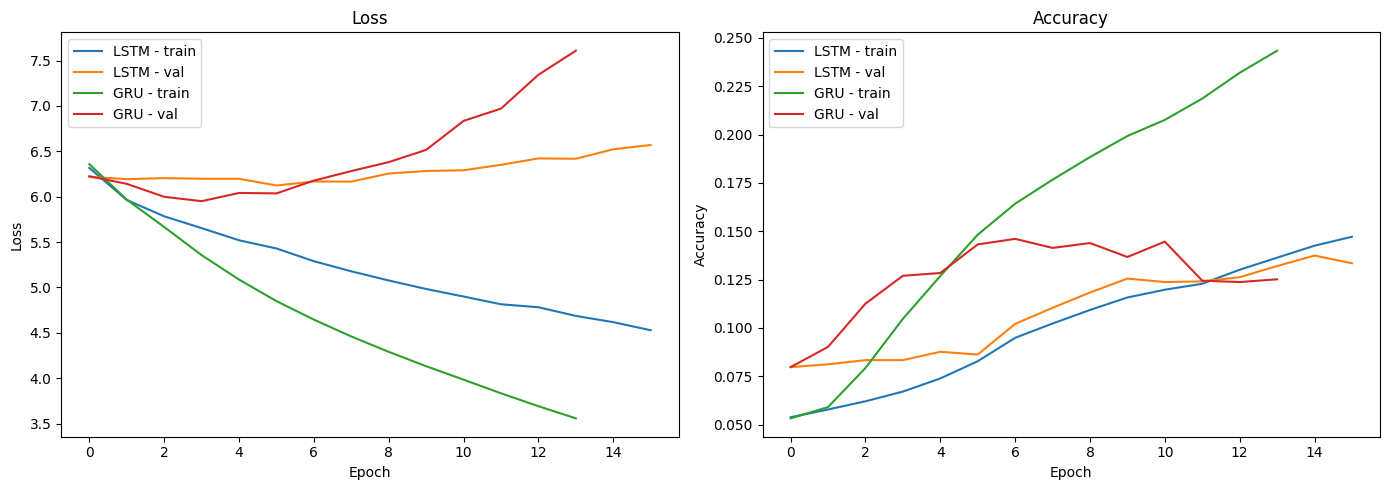

Model     Val Loss       Val Accuracy   
LSTM      6.5695         0.1334         
GRU       7.6082         0.1251         

LSTM generation:
 alice was beginning to all it the march and listeners perfectly tired me who ” one people the voice turtle hand to was ” another mock of things at as said the little little door i was ” the other here and the trial’s time and here of the lory in the mock turtle

GRU generation:
 alice was beginning to gone you as it was it was the butterfly of her caterpillar it was ” in the little about in a “now was door being furrow and she was her to herself her spoke as she began “and it at the mock and twinkling into its king but the room


In [26]:
import matplotlib.pyplot as plt

# --- Training curves: loss ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(word_history.history["loss"], label="LSTM - train")
axes[0].plot(word_history.history["val_loss"], label="LSTM - val")
axes[0].plot(gru_history.history["loss"], label="GRU - train")
axes[0].plot(gru_history.history["val_loss"], label="GRU - val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

# --- Training curves: accuracy ---
axes[1].plot(word_history.history["accuracy"], label="LSTM - train")
axes[1].plot(word_history.history["val_accuracy"], label="LSTM - val")
axes[1].plot(gru_history.history["accuracy"], label="GRU - train")
axes[1].plot(gru_history.history["val_accuracy"], label="GRU - val")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

# --- Final metrics table ---
lstm_val_loss = word_history.history["val_loss"][-1]
lstm_val_acc = word_history.history["val_accuracy"][-1]
gru_val_loss = gru_history.history["val_loss"][-1]
gru_val_acc = gru_history.history["val_accuracy"][-1]

print(f"{'Model':<10}{'Val Loss':<15}{'Val Accuracy':<15}")
print(f"{'LSTM':<10}{lstm_val_loss:<15.4f}{lstm_val_acc:<15.4f}")
print(f"{'GRU':<10}{gru_val_loss:<15.4f}{gru_val_acc:<15.4f}")

# --- Side-by-side text generation ---
seed = "alice was beginning to"

lstm_output = generate_word_text(word_model, word_tokenizer, seed, num_words=50, temperature=0.7)
gru_output = generate_word_text(gru_model, word_tokenizer, seed, num_words=50, temperature=0.7)

print("\nLSTM generation:\n", lstm_output)
print("\nGRU generation:\n", gru_output)
